# package


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import minimize
from matplotlib import colors as mcolors

import package_Lab
from package_Lab import LL_RT, PID_RT
import package_DBR
import package_Lab
from package_DBR import myRound, SelectPath_RT, Delay_RT, FO_RT, FOPDT, SOPDT, FOPDT_cost, SOPDT_cost, Process, Bode
from package_Lab import LL_RT

from importlib import reload
package_Lab=reload(package_Lab)

# LL_RT()

In [6]:
help(LL_RT)

Help on function LL_RT in module package_Lab:

LL_RT(MV, Kp, Tlag, Tlead, Ts, PV, PVInit=0, method='EBD')
    The function "LL_RT" needs to be included in a "for or while loop".

    :MV: input vector
    :Kp: process gain
    :T: lag time constant [s]
    :Ts: sampling period [s]
    :PV: output vector
    :PVInit: (optional: default value is 0)
    :method: discretisation method (optional: default value is 'EBD')
        EBD: Euler Backward difference
        EFD: Euler Forward difference
        TRAP: Trapezoïdal method

    The function "LL_RT" appends a value to the output vector "PV".
    The appended value is obtained from a recurrent equation that depends on the discretisation method.



(0.0, 100.0)

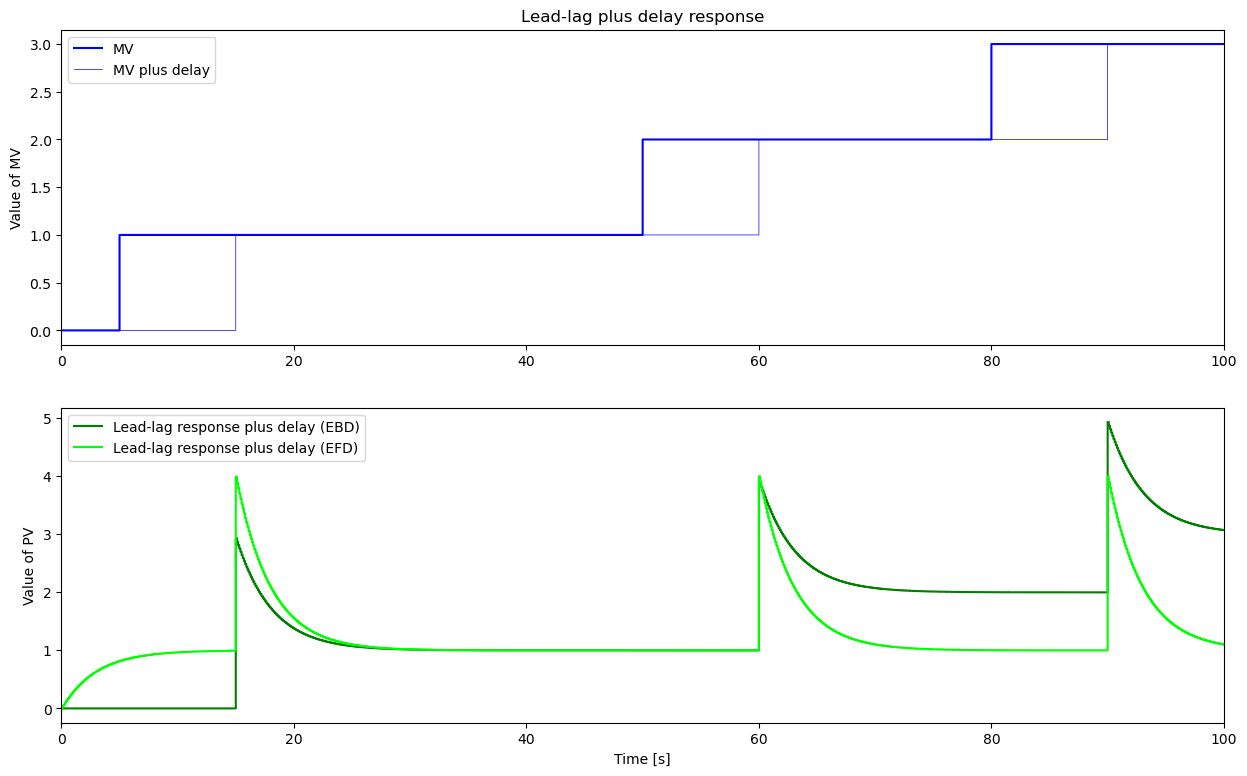

In [7]:
TSim = 100
Ts = 0.1
N = int(TSim/Ts) + 1

# Path for MV en gros ça va être un step de 0 à 1 à t=5s, puis un step de 1 à 2 à t=50s, puis un step de 2 à 3 à t=80s, et enfin un step de 3 à 3 à t=100s (pas de changement)
MVPath = {0: 0, 5: 1, 50: 2, 80: 3, TSim: 3}

t = []
MV = []
MVDelay = []
PV_EBD = []
PV_EFD = []
PV_TRAP = []

# Parameters
Kp = 1
Tlag = 3
Tlead = 9
theta = 10

for i in range(0,N):
    t.append(i*Ts)
    SelectPath_RT(MVPath,t,MV)
    Delay_RT(MV,theta,Ts,MVDelay)
    LL_RT(MVDelay,Kp,Tlag,Tlead,Ts,PV_EBD)
    LL_RT(MVDelay,Kp,Tlag,Tlead,Ts,PV_EFD,0,'EFD')
    #LL_RT(MVDelay,Kp,Tlag,Tlead,Ts,PV_TRAP,0,'TRAP')
    
plt.figure(figsize = (15,9))

plt.subplot(2,1,1)
plt.step(t,MV,'b-',label='MV',where='post')
plt.step(t,MVDelay,'b-',linewidth=0.5,label='MV plus delay',where='post')
plt.ylabel('Value of MV')
plt.title('Lead-lag plus delay response')
plt.legend(loc='best')
plt.xlim([0, TSim])

plt.subplot(2,1,2)
plt.step(t,PV_EBD,'g-',label='Lead-lag response plus delay (EBD)',where='post')
plt.step(t,PV_EFD,'lime',label='Lead-lag response plus delay (EFD)',where='post')
#plt.step(t,PV_TRAP,'springgreen',label='Lead-lag response plus delay (TRAP)',where='post')
plt.ylabel('Value of PV')
plt.xlabel('Time [s]')
plt.legend(loc='best')
plt.xlim([0, TSim])    

# PID


(0.0, 100.0)

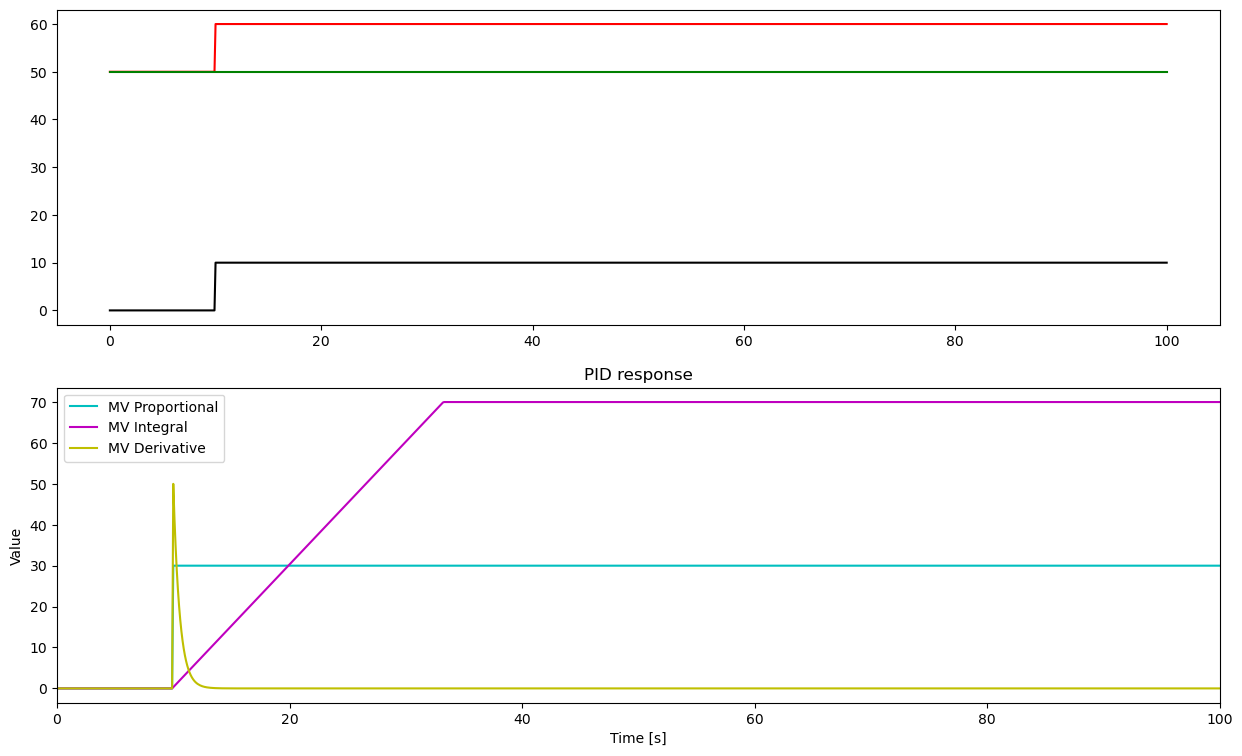

In [8]:
TSim = 100
Ts = 0.1
N = int(TSim/Ts) + 1

#para
Kc = 3
Ti = 10
Td = 1
alpha = 0.5
MVMAx = 100
MVMin = 0
MVMan = 50


MVPath = {0: 0, 5: 1, 50: 2, 80: 3, TSim: 3}
SPPath = {0: 50, 10: 60, 50: 60, 100: 60, TSim: 60}
PVPath = {0: 50, 5: 50, 50: 50, 100: 50, TSim: 50}
MANPath = {0: False, 5: False, 50: False, 100: False, TSim: False}
MVFFPath = {0: 0, 5: 0, 50: 0, 100: 15, TSim: 0}


t= []
PV = []
SP = []
MAN = []
MV = []
MVFF = []
MVP = []
MVI = []
MVD = []
E = []
for i in range(0,N):
    t.append(i*Ts)
    SelectPath_RT(MVPath,t,MV)
    SelectPath_RT(SPPath,t,SP)
    SelectPath_RT(PVPath,t,PV)
    SelectPath_RT(MANPath,t,MAN)
    SelectPath_RT(MVFFPath,t,MVFF)
    PID_RT(SP, PV,MAN,MVMan, MVFF, Kc, Ti, Td, alpha, Ts, MVMin, MVMAx, MV, MVP, MVI, MVD, E,PVInit=50)

plt.figure(figsize = (15,9))

plt.subplot(2,1,1)
plt.plot(t,SP,'r-',label='SP')
plt.plot(t,PV,'g-',label='PV')
plt.plot(t,E,'k-',label='Error')
plt.subplot(2,1,2)
#plt.plot(t,MV,'b-',label='MV')
plt.plot(t,MVP,'c-',label='MV Proportional')
plt.plot(t,MVI,'m-',label='MV Integral')
plt.plot(t,MVD,'y-',label='MV Derivative')
#plt.plot(t,MVFF,'m-',label='MVFF')
plt.ylabel('Value')
plt.xlabel('Time [s]')
plt.title('PID response')
plt.legend(loc='best')
plt.xlim([0, TSim]) 

# Simulation CLP PID FF

In [ ]:
TSim = 100
Ts = 0.1
N = int(TSim/Ts) + 1

MV0 = 50
DV0 = 50
PV0 = #point de fonctionement

#Paramètres du PID
Kp = 0.3768941279826313
T1p = 187.1409297022807
T2p = 10.452990644869
thetap = 13.137983829128451 

#Paramètres de la perturbation
Kd = 0.3241048096246215
T1d = 221.16602071422838
T2d = 16.741635805529068
thetad = 5.453465939559135
